<a href="https://colab.research.google.com/github/jonabersaesime/Actividad5/blob/main/Actividad5_Titanic_MLflow_Entrega_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 5. Preparación, entrenamiento y seguimiento de modelos con MLflow

**Proyecto:** Clasificación de supervivencia con el dataset Titanic  
**Entorno de ejecución:** Google Colab  
**Seguimiento de experimentos:** MLflow con almacenamiento SQLite  
**Evidencia principal:** Registro programático de cuatro experimentos, métricas, parámetros, modelos y artefactos  

> Este notebook está diseñado para ejecutarse completamente en Google Colab. La comprobación del registro de experimentos se realiza directamente mediante la API de MLflow, sin depender de una interfaz web externa.


# Introducción

En esta actividad se desarrolla un flujo completo de aprendizaje automático utilizando el conjunto de datos Titanic. El proyecto abarca la carga y exploración de la información, limpieza y preparación de los datos, entrenamiento de modelos de clasificación, ajuste de hiperparámetros, validación cruzada, registro de experimentos con MLflow y comparación de resultados.

Se emplean dos algoritmos: Regresión Logística y Random Forest. La variable objetivo es `survived`, que indica si un pasajero sobrevivió o no. Para evitar conclusiones engañosas, se excluyen variables que duplican o revelan directamente la respuesta, como `alive`.


# Objetivo general

Preparar y versionar el conjunto de datos Titanic, entrenar modelos de clasificación, optimizar sus hiperparámetros y registrar parámetros, métricas, modelos y artefactos mediante MLflow, con el propósito de comparar resultados de manera reproducible y seleccionar la mejor alternativa.


# Flujo de trabajo

1. Preparación del entorno y configuración reproducible.
2. Carga, exploración y versionamiento del dataset Titanic.
3. Limpieza y preparación de variables.
4. División de datos y construcción del preprocesamiento.
5. Entrenamiento de Regresión Logística y Random Forest.
6. Ajuste de hiperparámetros mediante GridSearchCV.
7. Validación cruzada de los mejores modelos.
8. Registro de cuatro experimentos en MLflow.
9. Verificación programática del registro y generación de evidencias.
10. Comparación final y selección del mejor modelo.


# 1. Preparación del entorno

## ¿Qué se realizará?

Se instalarán e importarán las bibliotecas necesarias, se crearán las carpetas del proyecto y se verificará el funcionamiento de MLflow.

## Resultado esperado

Un entorno funcional y organizado para ejecutar todas las fases del proyecto.


In [1]:
# ============================================================
# 1.1 Instalación de MLflow
# ============================================================

%pip install -q --upgrade mlflow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.

In [2]:
# ============================================================
# 1.2 Importación de bibliotecas
# ============================================================

import os
import sys
import json
import hashlib
import platform
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

print("Bibliotecas importadas correctamente.")


Bibliotecas importadas correctamente.


In [3]:
# ============================================================
# 1.3 Verificación de versiones
# ============================================================

versiones = {
    "Sistema operativo": f"{platform.system()} {platform.release()}",
    "Python": sys.version.split()[0],
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "Scikit-learn": sklearn.__version__,
    "MLflow": mlflow.__version__,
    "Seaborn": sns.__version__
}

for nombre, version in versiones.items():
    print(f"{nombre}: {version}")


Sistema operativo: Linux 6.6.122+
Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn: 1.6.1
MLflow: 3.14.0
Seaborn: 0.13.2


In [4]:
# ============================================================
# 1.4 Creación de carpetas
# ============================================================

CARPETAS = [
    "datos/datos_ini",
    "datos/datos_limp",
    "artefactos",
    "resultados",
    "evidencias"
]

for carpeta in CARPETAS:
    Path(carpeta).mkdir(parents=True, exist_ok=True)

print("Carpetas creadas:")
for carpeta in CARPETAS:
    print(f"- {carpeta}")


Carpetas creadas:
- datos/datos_ini
- datos/datos_limp
- artefactos
- resultados
- evidencias


In [5]:
# ============================================================
# 1.5 Configuración reproducible de MLflow
# ============================================================

NOMBRE_EXPERIMENTO = "Actividad5_Titanic"
MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"

# Al ejecutar todo el notebook se limpia el registro anterior para evitar
# corridas duplicadas y conservar exactamente los cuatro experimentos.
REINICIAR_REGISTRO_MLFLOW = True

if REINICIAR_REGISTRO_MLFLOW:
    archivos_sqlite = [
        "mlflow.db",
        "mlflow.db-shm",
        "mlflow.db-wal"
    ]

    for archivo in archivos_sqlite:
        ruta = Path(archivo)
        if ruta.exists():
            ruta.unlink()

    for carpeta in ["mlartifacts", "mlruns"]:
        ruta = Path(carpeta)
        if ruta.exists():
            shutil.rmtree(ruta)

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
experimento = mlflow.set_experiment(NOMBRE_EXPERIMENTO)

print("MLflow configurado correctamente.")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experimento: {NOMBRE_EXPERIMENTO}")
print(f"ID del experimento: {experimento.experiment_id}")
print("El registro está limpio y listo para recibir cuatro corridas.")


2026/07/17 03:41:20 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/17 03:41:20 INFO mlflow.store.db.utils: Updating database tables
2026/07/17 03:41:27 INFO mlflow.tracking.fluent: Experiment with name 'Actividad5_Titanic' does not exist. Creating a new experiment.


MLflow configurado correctamente.
Tracking URI: sqlite:///mlflow.db
Experimento: Actividad5_Titanic
ID del experimento: 1
El registro está limpio y listo para recibir cuatro corridas.


## Conclusión de la fase 1

El entorno quedó configurado con las bibliotecas necesarias y una base SQLite limpia para MLflow. Esta configuración evita duplicados cuando se ejecuta todo el notebook y permite demostrar de forma reproducible el registro de exactamente cuatro experimentos.


# 2. Carga y exploración inicial del dataset

## ¿Qué se realizará?

Se cargará el dataset Titanic, se guardará una copia original y se analizarán sus dimensiones, tipos de datos, valores faltantes, duplicados y distribuciones principales.

## Resultado esperado

Comprender la estructura y calidad inicial de los datos antes de limpiarlos.


In [6]:
# ============================================================
# 2.1 Carga del dataset Titanic
# ============================================================

df_original = sns.load_dataset("titanic")
df = df_original.copy()

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
display(df.head())


Dataset cargado correctamente.
Filas: 891
Columnas: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
# ============================================================
# 2.2 Guardado y huella digital de la versión original
# ============================================================

RUTA_ORIGINAL = "datos/datos_ini/titanic_original.csv"
df_original.to_csv(RUTA_ORIGINAL, index=False)

def calcular_sha256(ruta):
    sha256 = hashlib.sha256()
    with open(ruta, "rb") as archivo:
        for bloque in iter(lambda: archivo.read(4096), b""):
            sha256.update(bloque)
    return sha256.hexdigest()

hash_original = calcular_sha256(RUTA_ORIGINAL)

print("Archivo original:", RUTA_ORIGINAL)
print("SHA-256:", hash_original)


Archivo original: datos/datos_ini/titanic_original.csv
SHA-256: 81787d320d7f7b03df935e91de8bd19e11d45c5bbcab86ef4d4a76dc91b7d4f2


In [8]:
# ============================================================
# 2.3 Tipos de datos e información general
# ============================================================

df.info()

resumen_tipos = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.astype(str).values,
    "Valores únicos": df.nunique().values
})

display(resumen_tipos)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,Variable,Tipo,Valores únicos
0,survived,int64,2
1,pclass,int64,3
2,sex,object,2
3,age,float64,88
4,sibsp,int64,7
5,parch,int64,7
6,fare,float64,248
7,embarked,object,3
8,class,category,3
9,who,object,3


In [9]:
# ============================================================
# 2.4 Estadísticas descriptivas
# ============================================================

display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0000,NaN,NaN,NaN,0.3838,0.4866,0.0000,0.0000,0.0000,1.0000,1.0000
pclass,891.0000,NaN,NaN,NaN,2.3086,0.8361,1.0000,2.0000,3.0000,3.0000,3.0000
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0000,NaN,NaN,NaN,29.6991,14.5265,0.4200,20.1250,28.0000,38.0000,80.0000
sibsp,891.0000,NaN,NaN,NaN,0.5230,1.1027,0.0000,0.0000,0.0000,1.0000,8.0000
parch,891.0000,NaN,NaN,NaN,0.3816,0.8061,0.0000,0.0000,0.0000,0.0000,6.0000
fare,891.0000,NaN,NaN,NaN,32.2042,49.6934,0.0000,7.9104,14.4542,31.0000,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# ============================================================
# 2.5 Valores faltantes y duplicados
# ============================================================

resumen_calidad = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "No nulos": df.notna().sum(),
    "Nulos": df.isna().sum(),
    "Porcentaje nulos (%)": (df.isna().mean() * 100).round(2),
    "Valores únicos": df.nunique()
}).sort_values("Porcentaje nulos (%)", ascending=False)

display(resumen_calidad)

duplicados = df.duplicated().sum()
print(f"Registros duplicados considerando todas las columnas: {duplicados}")


,Tipo,No nulos,Nulos,Porcentaje nulos (%),Valores únicos
deck,category,203,688,77.2200,7
age,float64,714,177,19.8700,88
embarked,object,889,2,0.2200,3
embark_town,object,889,2,0.2200,3
sex,object,891,0,0.0000,2
pclass,int64,891,0,0.0000,3
survived,int64,891,0,0.0000,2
fare,float64,891,0,0.0000,248
parch,int64,891,0,0.0000,7
sibsp,int64,891,0,0.0000,7


Registros duplicados considerando todas las columnas: 107


,Cantidad,Porcentaje (%)
No sobrevivió,549,61.6200
Sobrevivió,342,38.3800


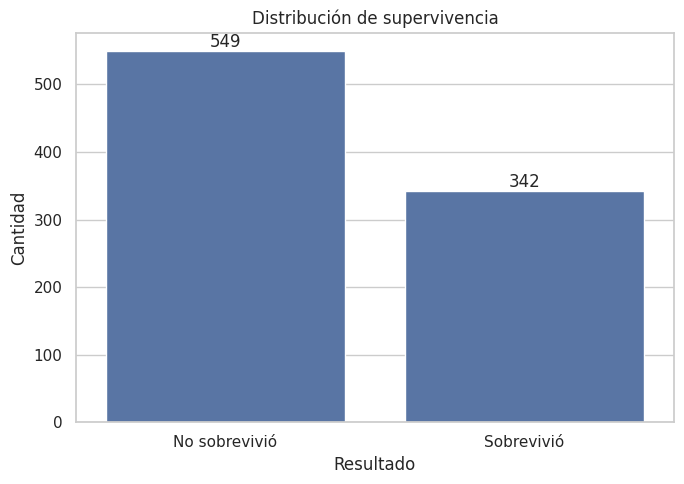

In [11]:
# ============================================================
# 2.6 Distribución de la variable objetivo
# ============================================================

tabla_objetivo = pd.DataFrame({
    "Cantidad": df["survived"].value_counts().sort_index(),
    "Porcentaje (%)": (
        df["survived"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})
tabla_objetivo.index = ["No sobrevivió", "Sobrevivió"]
display(tabla_objetivo)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="survived")
ax.set_title("Distribución de supervivencia")
ax.set_xlabel("Resultado")
ax.set_ylabel("Cantidad")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No sobrevivió", "Sobrevivió"])
for contenedor in ax.containers:
    ax.bar_label(contenedor)
plt.tight_layout()
plt.show()


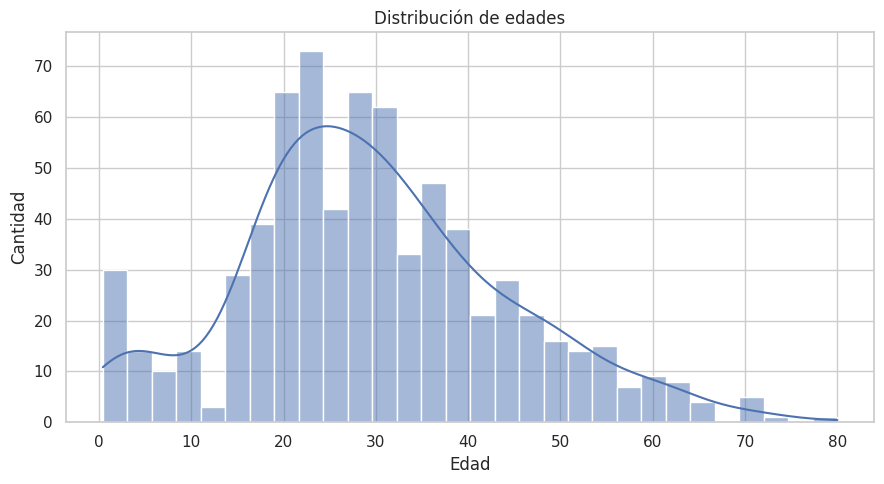

In [12]:
# ============================================================
# 2.7 Distribución de edad
# ============================================================

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="age", bins=30, kde=True)
plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()


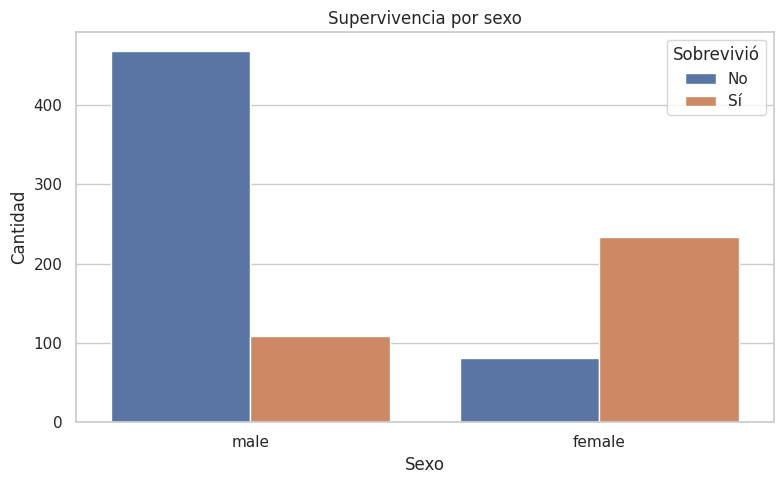

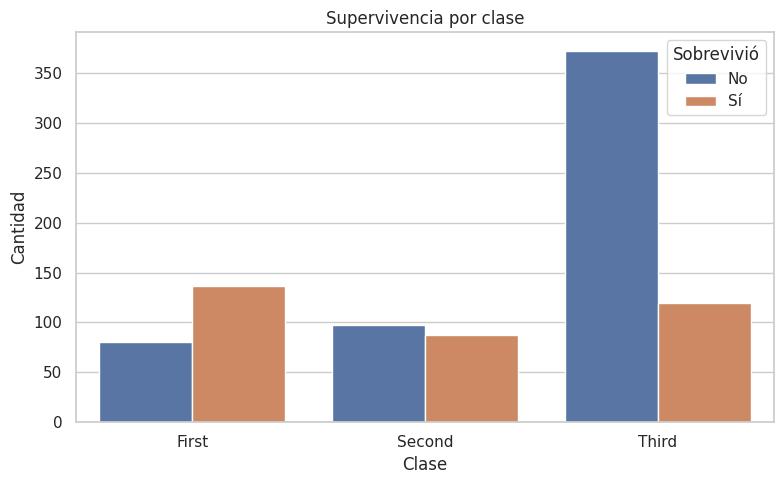

In [13]:
# ============================================================
# 2.8 Supervivencia por sexo y clase
# ============================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Supervivencia por sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad")
plt.legend(title="Sobrevivió", labels=["No", "Sí"])
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="class", hue="survived")
plt.title("Supervivencia por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.legend(title="Sobrevivió", labels=["No", "Sí"])
plt.tight_layout()
plt.show()


## Primeras observaciones

- El dataset contiene 891 registros y 15 variables.
- La variable objetivo es `survived`.
- Existen valores faltantes principalmente en `deck` y `age`.
- Hay más pasajeros no sobrevivientes que sobrevivientes.
- El sexo y la clase presentan diferencias visibles respecto a la supervivencia.
- Algunas variables son redundantes o revelan la respuesta, por lo que no deben utilizarse en el modelo.


# 3. Limpieza y preparación de los datos

## ¿Qué se realizará?

Se seleccionarán variables predictoras apropiadas, se eliminarán variables redundantes o con fuga de información, se imputarán valores faltantes y se guardará una versión limpia del dataset.

## Decisiones de preparación

Se utilizarán:

- `pclass`: clase numérica del pasajero.
- `sex`: sexo.
- `age`: edad.
- `sibsp`: familiares tipo hermano/cónyuge.
- `parch`: padres/hijos.
- `fare`: tarifa.
- `embarked`: puerto de embarque.
- `alone`: si viajaba solo.

Se excluirán variables como `alive`, porque representa directamente la variable objetivo, y otras variables redundantes como `class`, `who`, `adult_male` y `embark_town`.


In [14]:
# ============================================================
# 3.1 Selección de variables
# ============================================================

VARIABLE_OBJETIVO = "survived"

VARIABLES_MODELO = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
    "alone"
]

df_modelo = df[VARIABLES_MODELO + [VARIABLE_OBJETIVO]].copy()

print("Variables seleccionadas:")
print(VARIABLES_MODELO)
display(df_modelo.head())


Variables seleccionadas:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


,pclass,sex,age,sibsp,parch,fare,embarked,alone,survived
0,3,male,22.0000,1,0,7.2500,S,False,0
1,1,female,38.0000,1,0,71.2833,C,False,1
2,3,female,26.0000,0,0,7.9250,S,True,1
3,1,female,35.0000,1,0,53.1000,S,False,1
4,3,male,35.0000,0,0,8.0500,S,True,0


In [15]:
# ============================================================
# 3.2 Revisión de valores faltantes en variables seleccionadas
# ============================================================

faltantes_modelo = pd.DataFrame({
    "Nulos": df_modelo.isna().sum(),
    "Porcentaje (%)": (df_modelo.isna().mean() * 100).round(2)
})

display(faltantes_modelo)


,Nulos,Porcentaje (%)
pclass,0,0.0000
sex,0,0.0000
age,177,19.8700
sibsp,0,0.0000
parch,0,0.0000
fare,0,0.0000
embarked,2,0.2200
alone,0,0.0000
survived,0,0.0000


In [16]:
# ============================================================
# 3.3 Creación de una versión limpia e interpretable
# ============================================================

df_limpio = df_modelo.copy()

df_limpio["age"] = df_limpio["age"].fillna(df_limpio["age"].median())
df_limpio["fare"] = df_limpio["fare"].fillna(df_limpio["fare"].median())
df_limpio["embarked"] = df_limpio["embarked"].fillna(
    df_limpio["embarked"].mode()[0]
)

df_limpio["alone"] = df_limpio["alone"].astype(int)

RUTA_LIMPIA = "datos/datos_limp/titanic_limpio.csv"
df_limpio.to_csv(RUTA_LIMPIA, index=False)

hash_limpio = calcular_sha256(RUTA_LIMPIA)

print("Dataset limpio guardado en:", RUTA_LIMPIA)
print("SHA-256:", hash_limpio)
print("Valores nulos restantes:", int(df_limpio.isna().sum().sum()))
display(df_limpio.head())


Dataset limpio guardado en: datos/datos_limp/titanic_limpio.csv
SHA-256: eb90d6abef8c751d7d75b3b6d578467beef546e342989559ff795aac3935883b
Valores nulos restantes: 0


,pclass,sex,age,sibsp,parch,fare,embarked,alone,survived
0,3,male,22.0000,1,0,7.2500,S,0,0
1,1,female,38.0000,1,0,71.2833,C,0,1
2,3,female,26.0000,0,0,7.9250,S,1,1
3,1,female,35.0000,1,0,53.1000,S,0,1
4,3,male,35.0000,0,0,8.0500,S,1,0


In [17]:
# ============================================================
# 3.4 Registro de versiones de datos
# ============================================================

versiones_datos = pd.DataFrame([
    {
        "Versión": "v1_original",
        "Archivo": RUTA_ORIGINAL,
        "Filas": df_original.shape[0],
        "Columnas": df_original.shape[1],
        "SHA-256": hash_original
    },
    {
        "Versión": "v2_limpia",
        "Archivo": RUTA_LIMPIA,
        "Filas": df_limpio.shape[0],
        "Columnas": df_limpio.shape[1],
        "SHA-256": hash_limpio
    }
])

RUTA_VERSIONES = "resultados/versiones_datos.csv"
versiones_datos.to_csv(RUTA_VERSIONES, index=False)

display(versiones_datos)


,Versión,Archivo,Filas,Columnas,SHA-256
0,v1_original,datos/datos_ini/titanic_original.csv,891,15,81787d320d7f7b03df935e91de8bd19e11d45c5bbcab86...
1,v2_limpia,datos/datos_limp/titanic_limpio.csv,891,9,eb90d6abef8c751d7d75b3b6d578467beef546e3429895...


## Conclusión de la fase 3

Se creó una versión limpia del dataset con variables relevantes para la predicción. Los valores faltantes fueron imputados y se generaron huellas SHA-256 para identificar las versiones original y limpia.


# 4. Separación de datos y preprocesamiento

## ¿Qué se realizará?

Se dividirán los datos en conjuntos de entrenamiento y prueba. Después se construirá un preprocesador que impute valores, estandarice variables numéricas y transforme variables categóricas mediante codificación One-Hot.

## Resultado esperado

Obtener conjuntos independientes para entrenar y evaluar los modelos sin fuga de información.


In [18]:
# ============================================================
# 4.1 Separación de variables predictoras y objetivo
# ============================================================

X = df_modelo[VARIABLES_MODELO].copy()
y = df_modelo[VARIABLE_OBJETIVO].copy()

columnas_numericas = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

columnas_categoricas = [
    "sex",
    "embarked",
    "alone"
]

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)


Dimensión de X: (891, 8)
Dimensión de y: (891,)


In [19]:
# ============================================================
# 4.2 Train/Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)
print("\nDistribución de y_train:")
display(y_train.value_counts(normalize=True).rename("Proporción"))
print("\nDistribución de y_test:")
display(y_test.value_counts(normalize=True).rename("Proporción"))


Entrenamiento: (712, 8)
Prueba: (179, 8)

Distribución de y_train:


,Proporción
survived,
0,0.6166
1,0.3834



Distribución de y_test:


,Proporción
survived,
0,0.6145
1,0.3855


In [20]:
# ============================================================
# 4.3 Pipeline de preprocesamiento
# ============================================================

pipeline_numerico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalado", StandardScaler())
])

pipeline_categorico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer(
    transformers=[
        ("numericas", pipeline_numerico, columnas_numericas),
        ("categoricas", pipeline_categorico, columnas_categoricas)
    ]
)

print("Pipeline de preprocesamiento creado correctamente.")


Pipeline de preprocesamiento creado correctamente.


In [21]:
# ============================================================
# 4.4 Funciones auxiliares de evaluación
# ============================================================

def calcular_metricas(modelo, X_eval, y_real):
    predicciones = modelo.predict(X_eval)
    probabilidades = modelo.predict_proba(X_eval)[:, 1]

    return {
        "accuracy": accuracy_score(y_real, predicciones),
        "precision": precision_score(y_real, predicciones, zero_division=0),
        "recall": recall_score(y_real, predicciones, zero_division=0),
        "f1": f1_score(y_real, predicciones, zero_division=0),
        "roc_auc": roc_auc_score(y_real, probabilidades)
    }

def evaluar_y_mostrar(modelo, X_eval, y_real, nombre_modelo):
    predicciones = modelo.predict(X_eval)
    metricas = calcular_metricas(modelo, X_eval, y_real)

    print(f"Métricas de {nombre_modelo}")
    display(pd.DataFrame([metricas]).T.rename(columns={0: "Valor"}))

    print("\nReporte de clasificación:")
    print(classification_report(
        y_real,
        predicciones,
        target_names=["No sobrevivió", "Sobrevivió"],
        zero_division=0
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_real,
        predicciones,
        display_labels=["No sobrevivió", "Sobrevivió"],
        cmap="Blues"
    )
    plt.title(f"Matriz de confusión: {nombre_modelo}")
    plt.tight_layout()
    plt.show()

    RocCurveDisplay.from_estimator(modelo, X_eval, y_real)
    plt.title(f"Curva ROC: {nombre_modelo}")
    plt.tight_layout()
    plt.show()

    return metricas


# 5. Modelo 1: Regresión Logística

## ¿Qué se realizará?

Se entrenará una Regresión Logística utilizando el pipeline de preprocesamiento. El modelo será evaluado mediante accuracy, precision, recall, F1, ROC-AUC, reporte de clasificación y matriz de confusión.

## Resultado esperado

Establecer una línea base interpretable para comparar modelos posteriores.


In [22]:
# ============================================================
# 5.1 Creación y entrenamiento de Regresión Logística
# ============================================================

modelo_logistico = Pipeline(steps=[
    ("preprocesamiento", clone(preprocesador)),
    ("modelo", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

modelo_logistico.fit(X_train, y_train)

print("Regresión Logística entrenada correctamente.")


Regresión Logística entrenada correctamente.


Métricas de Regresión Logística


,Valor
accuracy,0.8045
precision,0.7833
recall,0.6812
f1,0.7287
roc_auc,0.8501



Reporte de clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.82      0.88      0.85       110
   Sobrevivió       0.78      0.68      0.73        69

     accuracy                           0.80       179
    macro avg       0.80      0.78      0.79       179
 weighted avg       0.80      0.80      0.80       179



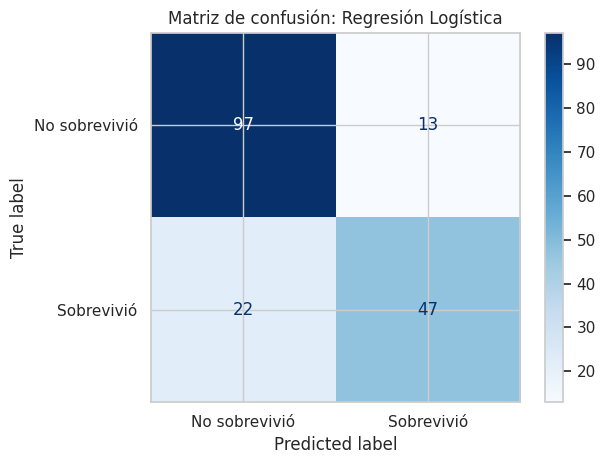

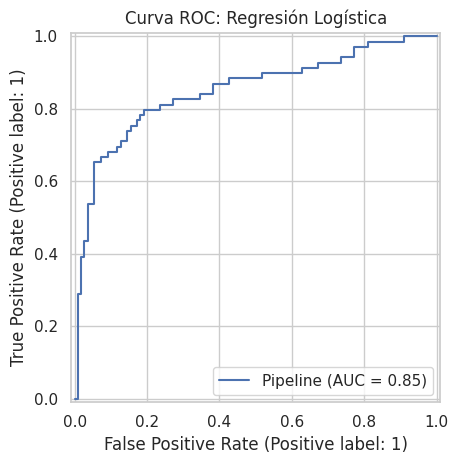

In [23]:
# ============================================================
# 5.2 Evaluación de Regresión Logística
# ============================================================

metricas_logistico = evaluar_y_mostrar(
    modelo_logistico,
    X_test,
    y_test,
    "Regresión Logística"
)


## Primeras conclusiones del modelo 1

La Regresión Logística funciona como modelo base porque permite estimar la probabilidad de supervivencia mediante una relación lineal entre las variables transformadas y la variable objetivo. Sus métricas permiten identificar si el modelo mantiene un equilibrio adecuado entre precisión y recuperación de sobrevivientes.

La matriz de confusión muestra los aciertos y errores para ambas clases, mientras que ROC-AUC permite evaluar la capacidad general de discriminación del modelo.


# 6. Modelo 2: Random Forest

## ¿Qué se realizará?

Se entrenará un Random Forest, algoritmo basado en múltiples árboles de decisión. Este modelo puede representar relaciones no lineales e interacciones más complejas.

## Resultado esperado

Comparar si un modelo de ensamble supera a la Regresión Logística.


In [24]:
# ============================================================
# 6.1 Creación y entrenamiento de Random Forest
# ============================================================

modelo_rf = Pipeline(steps=[
    ("preprocesamiento", clone(preprocesador)),
    ("modelo", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

modelo_rf.fit(X_train, y_train)

print("Random Forest entrenado correctamente.")


Random Forest entrenado correctamente.


Métricas de Random Forest


,Valor
accuracy,0.8101
precision,0.7869
recall,0.6957
f1,0.7385
roc_auc,0.8244



Reporte de clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.82      0.88      0.85       110
   Sobrevivió       0.79      0.70      0.74        69

     accuracy                           0.81       179
    macro avg       0.80      0.79      0.79       179
 weighted avg       0.81      0.81      0.81       179



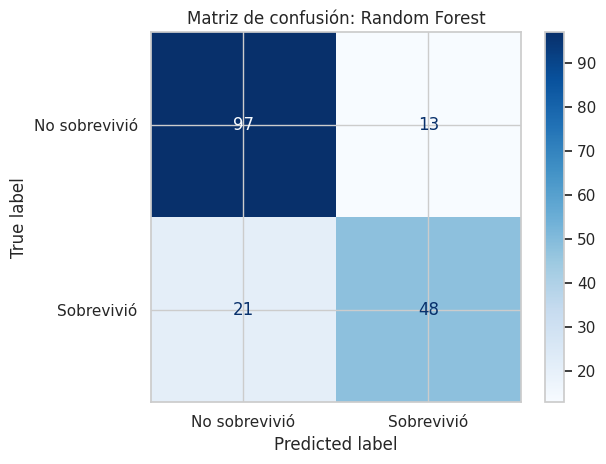

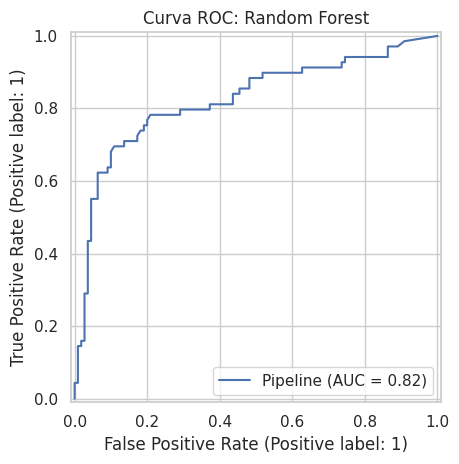

In [25]:
# ============================================================
# 6.2 Evaluación de Random Forest
# ============================================================

metricas_rf = evaluar_y_mostrar(
    modelo_rf,
    X_test,
    y_test,
    "Random Forest"
)


# 7. Ajuste de hiperparámetros

## ¿Qué se realizará?

Se empleará GridSearchCV con validación cruzada estratificada para probar diferentes configuraciones de ambos modelos. La métrica principal será ROC-AUC.

## Resultado esperado

Encontrar configuraciones con mejor capacidad de generalización.


In [26]:
# ============================================================
# 7.1 Configuración de validación cruzada
# ============================================================

cv_estratificada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Validación cruzada estratificada configurada con 5 particiones.")


Validación cruzada estratificada configurada con 5 particiones.


In [27]:
# ============================================================
# 7.2 GridSearchCV para Regresión Logística
# ============================================================

grid_logistico = {
    "modelo__C": [0.01, 0.1, 1, 10],
    "modelo__solver": ["liblinear", "lbfgs"],
    "modelo__class_weight": [None, "balanced"]
}

busqueda_logistico = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocesamiento", clone(preprocesador)),
        ("modelo", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),
    param_grid=grid_logistico,
    scoring="roc_auc",
    cv=cv_estratificada,
    n_jobs=-1,
    return_train_score=True
)

busqueda_logistico.fit(X_train, y_train)

mejor_logistico = busqueda_logistico.best_estimator_

print("Mejores parámetros:")
print(busqueda_logistico.best_params_)
print(f"Mejor ROC-AUC promedio de CV: {busqueda_logistico.best_score_:.4f}")


Mejores parámetros:
{'modelo__C': 0.1, 'modelo__class_weight': None, 'modelo__solver': 'liblinear'}
Mejor ROC-AUC promedio de CV: 0.8569


Métricas de Regresión Logística optimizada


,Valor
accuracy,0.8156
precision,0.8103
recall,0.6812
f1,0.7402
roc_auc,0.8506



Reporte de clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.82      0.90      0.86       110
   Sobrevivió       0.81      0.68      0.74        69

     accuracy                           0.82       179
    macro avg       0.81      0.79      0.80       179
 weighted avg       0.82      0.82      0.81       179



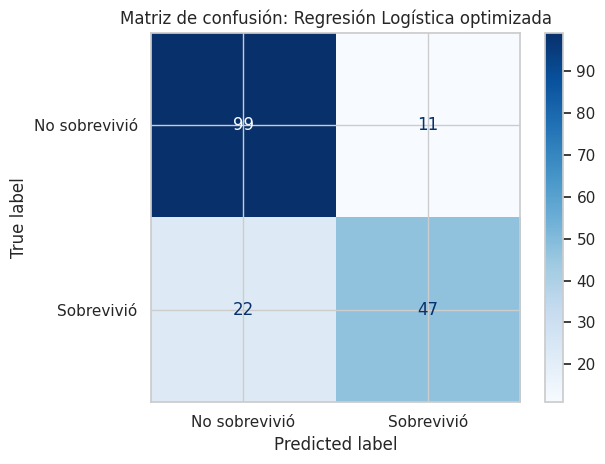

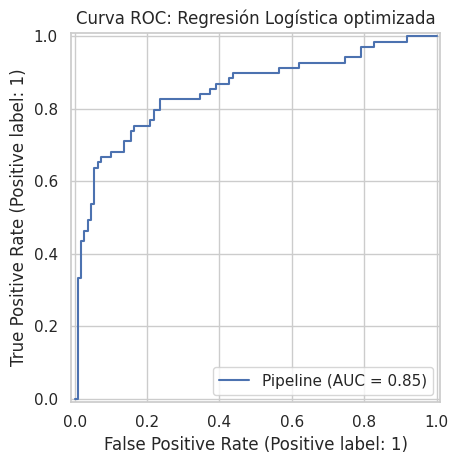

In [28]:
# ============================================================
# 7.3 Evaluación de Regresión Logística optimizada
# ============================================================

metricas_logistico_optimizado = evaluar_y_mostrar(
    mejor_logistico,
    X_test,
    y_test,
    "Regresión Logística optimizada"
)


In [29]:
# ============================================================
# 7.4 GridSearchCV para Random Forest
# ============================================================

grid_rf = {
    "modelo__n_estimators": [200, 400],
    "modelo__max_depth": [None, 5, 10],
    "modelo__min_samples_split": [2, 5],
    "modelo__min_samples_leaf": [1, 2],
    "modelo__class_weight": [None, "balanced"]
}

busqueda_rf = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocesamiento", clone(preprocesador)),
        ("modelo", RandomForestClassifier(
            random_state=42
        ))
    ]),
    param_grid=grid_rf,
    scoring="roc_auc",
    cv=cv_estratificada,
    n_jobs=-1,
    return_train_score=True
)

busqueda_rf.fit(X_train, y_train)

mejor_rf = busqueda_rf.best_estimator_

print("Mejores parámetros:")
print(busqueda_rf.best_params_)
print(f"Mejor ROC-AUC promedio de CV: {busqueda_rf.best_score_:.4f}")


Mejores parámetros:
{'modelo__class_weight': None, 'modelo__max_depth': None, 'modelo__min_samples_leaf': 2, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 200}
Mejor ROC-AUC promedio de CV: 0.8766


Métricas de Random Forest optimizado


,Valor
accuracy,0.8101
precision,0.8302
recall,0.6377
f1,0.7213
roc_auc,0.8361



Reporte de clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.80      0.92      0.86       110
   Sobrevivió       0.83      0.64      0.72        69

     accuracy                           0.81       179
    macro avg       0.82      0.78      0.79       179
 weighted avg       0.81      0.81      0.80       179



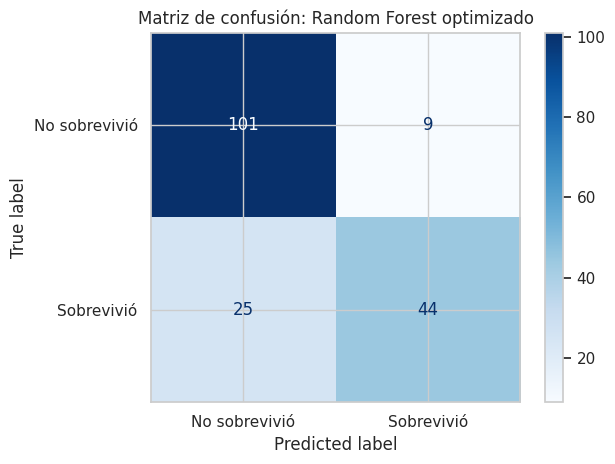

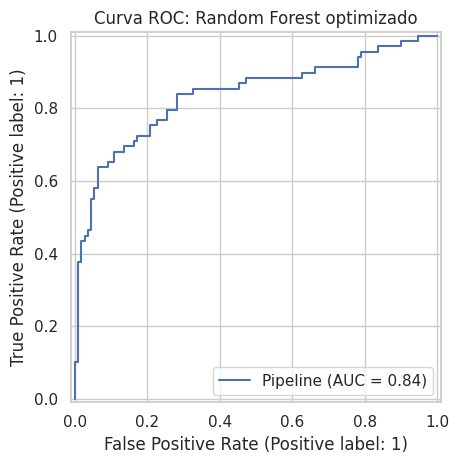

In [30]:
# ============================================================
# 7.5 Evaluación de Random Forest optimizado
# ============================================================

metricas_rf_optimizado = evaluar_y_mostrar(
    mejor_rf,
    X_test,
    y_test,
    "Random Forest optimizado"
)


# 8. Validación cruzada de los mejores modelos

## ¿Qué se realizará?

Se evaluarán los modelos optimizados mediante cinco particiones y varias métricas. Esto reduce la dependencia de una única división de entrenamiento y prueba.

## Resultado esperado

Obtener una estimación más estable del desempeño.


In [31]:
# ============================================================
# 8.1 Evaluación cruzada
# ============================================================

metricas_cv = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

modelos_optimizados = {
    "Regresión Logística optimizada": mejor_logistico,
    "Random Forest optimizado": mejor_rf
}

resultados_cv = []

for nombre, modelo in modelos_optimizados.items():
    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv_estratificada,
        scoring=metricas_cv,
        n_jobs=-1
    )

    fila = {"Modelo": nombre}

    for metrica in metricas_cv:
        valores = scores[f"test_{metrica}"]
        fila[f"{metrica}_media"] = valores.mean()
        fila[f"{metrica}_std"] = valores.std()

    resultados_cv.append(fila)

tabla_cv = pd.DataFrame(resultados_cv)
display(tabla_cv)


,Modelo,accuracy_media,accuracy_std,precision_media,precision_std,recall_media,recall_std,f1_media,f1_std,roc_auc_media,roc_auc_std
0,Regresión Logística optimizada,0.7992,0.0124,0.7640,0.0294,0.6925,0.0394,0.7252,0.0202,0.8569,0.0209
1,Random Forest optimizado,0.8132,0.0163,0.7881,0.0345,0.7033,0.0267,0.7427,0.0218,0.8766,0.0174


# 9. Registro y comprobación de experimentos con MLflow

## ¿Qué se realizará?

Se registrarán cuatro corridas: dos modelos base y dos modelos optimizados. Cada corrida almacenará:

- parámetros e hiperparámetros;
- métricas de evaluación;
- etiquetas descriptivas;
- huellas SHA-256 de los datos;
- matriz de confusión;
- archivo de versionamiento;
- modelo entrenado.

Después se consultará directamente la base de seguimiento de MLflow para comprobar que las cuatro corridas terminaron correctamente.

## Resultado esperado

Obtener una evidencia reproducible del seguimiento de experimentos sin depender de una interfaz web.


In [32]:
# ============================================================
# 9.1 Función para registrar modelos en MLflow
# Compatible con MLflow 3.x
# ============================================================

def registrar_modelo_mlflow(
    nombre_corrida,
    nombre_modelo,
    modelo,
    metricas,
    parametros_adicionales=None
):
    """Registra una corrida completa y devuelve su identificador."""

    predicciones = modelo.predict(X_test)
    matriz = confusion_matrix(y_test, predicciones)

    nombre_archivo = nombre_corrida.replace(" ", "_")
    ruta_matriz = f"artefactos/matriz_{nombre_archivo}.png"

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No sobrevivió", "Sobrevivió"],
        yticklabels=["No sobrevivió", "Sobrevivió"],
        ax=ax
    )
    ax.set_title(f"Matriz de confusión: {nombre_modelo}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    fig.tight_layout()
    fig.savefig(ruta_matriz, dpi=150, bbox_inches="tight")
    plt.close(fig)

    with mlflow.start_run(run_name=nombre_corrida) as corrida:
        mlflow.set_tag("modelo", nombre_modelo)
        mlflow.set_tag("dataset", "Titanic")
        mlflow.set_tag("tipo_problema", "clasificación binaria")
        mlflow.set_tag("entorno", "Google Colab")

        mlflow.log_param("random_state", 42)
        mlflow.log_param("test_size", 0.20)
        mlflow.log_param("hash_datos_originales", hash_original)
        mlflow.log_param("hash_datos_limpios", hash_limpio)

        if parametros_adicionales:
            for clave, valor in parametros_adicionales.items():
                mlflow.log_param(clave, str(valor))

        for nombre_metrica, valor in metricas.items():
            mlflow.log_metric(nombre_metrica, float(valor))

        mlflow.log_artifact(
            ruta_matriz,
            artifact_path="matrices_confusion"
        )
        mlflow.log_artifact(
            RUTA_VERSIONES,
            artifact_path="versionamiento"
        )

        # Pickle evita la validación de tipos de skops que puede generar
        # incompatibilidades con pipelines recientes de scikit-learn.
        mlflow.sklearn.log_model(
            sk_model=modelo,
            name="modelo",
            serialization_format="pickle"
        )

        run_id = corrida.info.run_id

    print(f"✓ {nombre_corrida} registrada | run_id: {run_id[:12]}...")
    return run_id


In [33]:
# ============================================================
# 9.2 Registro de los cuatro experimentos
# ============================================================

ids_corridas = {}

ids_corridas["01_logistica_base"] = registrar_modelo_mlflow(
    "01_logistica_base",
    "Regresión Logística",
    modelo_logistico,
    metricas_logistico,
    {
        "max_iter": 1000,
        "ajuste": "base"
    }
)

ids_corridas["02_random_forest_base"] = registrar_modelo_mlflow(
    "02_random_forest_base",
    "Random Forest",
    modelo_rf,
    metricas_rf,
    {
        "n_estimators": 300,
        "class_weight": "balanced",
        "ajuste": "base"
    }
)

ids_corridas["03_logistica_optimizada"] = registrar_modelo_mlflow(
    "03_logistica_optimizada",
    "Regresión Logística optimizada",
    mejor_logistico,
    metricas_logistico_optimizado,
    {
        **busqueda_logistico.best_params_,
        "cv_roc_auc": busqueda_logistico.best_score_,
        "ajuste": "GridSearchCV"
    }
)

ids_corridas["04_random_forest_optimizado"] = registrar_modelo_mlflow(
    "04_random_forest_optimizado",
    "Random Forest optimizado",
    mejor_rf,
    metricas_rf_optimizado,
    {
        **busqueda_rf.best_params_,
        "cv_roc_auc": busqueda_rf.best_score_,
        "ajuste": "GridSearchCV"
    }
)

print("\nRegistro finalizado.")
print(f"Total de corridas creadas en esta ejecución: {len(ids_corridas)}")


2026/07/17 03:44:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ 01_logistica_base registrada | run_id: b67261e00141...


2026/07/17 03:44:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ 02_random_forest_base registrada | run_id: 9ed47b9bb176...


2026/07/17 03:44:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ 03_logistica_optimizada registrada | run_id: 891a50982750...


2026/07/17 03:44:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ 04_random_forest_optimizado registrada | run_id: 29b160a3acd1...

Registro finalizado.
Total de corridas creadas en esta ejecución: 4


In [34]:
# ============================================================
# 9.3 Evidencia tabular de corridas registradas
# ============================================================

experimento = mlflow.get_experiment_by_name(NOMBRE_EXPERIMENTO)

corridas_mlflow = mlflow.search_runs(
    experiment_ids=[experimento.experiment_id],
    order_by=["attributes.start_time ASC"]
)

columnas_deseadas = [
    "tags.mlflow.runName",
    "tags.modelo",
    "metrics.accuracy",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1",
    "metrics.roc_auc",
    "status",
    "run_id"
]

columnas_interes = [
    columna for columna in columnas_deseadas
    if columna in corridas_mlflow.columns
]

tabla_corridas = corridas_mlflow[columnas_interes].copy()

renombrar = {
    "tags.mlflow.runName": "Corrida",
    "tags.modelo": "Modelo",
    "metrics.accuracy": "Accuracy",
    "metrics.precision": "Precision",
    "metrics.recall": "Recall",
    "metrics.f1": "F1",
    "metrics.roc_auc": "ROC_AUC",
    "status": "Estado",
    "run_id": "Run_ID"
}

tabla_corridas = tabla_corridas.rename(columns=renombrar)

RUTA_EVIDENCIA_MLFLOW = "evidencias/registro_experimentos_mlflow.csv"
tabla_corridas.to_csv(RUTA_EVIDENCIA_MLFLOW, index=False)

display(
    tabla_corridas.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    })
    .set_caption("Evidencia de experimentos registrados en MLflow")
)

print(f"Evidencia guardada en: {RUTA_EVIDENCIA_MLFLOW}")


,Corrida,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Estado,Run_ID
0,01_logistica_base,Regresión Logística,0.8045,0.7833,0.6812,0.7287,0.8501,FINISHED,b67261e0014142ab864366f4c13d54a1
1,02_random_forest_base,Random Forest,0.8101,0.7869,0.6957,0.7385,0.8244,FINISHED,9ed47b9bb176473e84708ae393229374
2,03_logistica_optimizada,Regresión Logística optimizada,0.8156,0.8103,0.6812,0.7402,0.8506,FINISHED,891a50982750417da5f7913d92cbbea1
3,04_random_forest_optimizado,Random Forest optimizado,0.8101,0.8302,0.6377,0.7213,0.8361,FINISHED,29b160a3acd14520ae1ccac7309997d7


Evidencia guardada en: evidencias/registro_experimentos_mlflow.csv


## 9.4 Verificación automática del registro

La siguiente celda funciona como una prueba de control. El notebook solo considera correcto el seguimiento cuando existen exactamente cuatro corridas, todas terminaron con estado `FINISHED` y sus nombres coinciden con los experimentos planeados.


In [35]:
# ============================================================
# 9.4 Verificación automática del registro
# ============================================================

corridas_esperadas = {
    "01_logistica_base",
    "02_random_forest_base",
    "03_logistica_optimizada",
    "04_random_forest_optimizado"
}

corridas_encontradas = set(tabla_corridas["Corrida"])
estados_correctos = tabla_corridas["Estado"].eq("FINISHED").all()
cantidad_correcta = len(tabla_corridas) == 4
nombres_correctos = corridas_encontradas == corridas_esperadas

assert cantidad_correcta, (
    f"Se esperaban 4 corridas y se encontraron {len(tabla_corridas)}."
)
assert nombres_correctos, (
    "Los nombres de las corridas no coinciden con los experimentos esperados."
)
assert estados_correctos, (
    "Una o más corridas no terminaron correctamente."
)

print("COMPROBACIÓN DE MLFLOW")
print("=" * 55)
print("✓ Experimento encontrado:", NOMBRE_EXPERIMENTO)
print("✓ Total de corridas:", len(tabla_corridas))
print("✓ Las cuatro corridas esperadas están presentes")
print("✓ Todas las corridas tienen estado FINISHED")
print("✓ Parámetros, métricas, modelos y artefactos fueron registrados")
print("=" * 55)
print("RESULTADO: REGISTRO DE EXPERIMENTOS COMPLETADO CORRECTAMENTE")


COMPROBACIÓN DE MLFLOW
✓ Experimento encontrado: Actividad5_Titanic
✓ Total de corridas: 4
✓ Las cuatro corridas esperadas están presentes
✓ Todas las corridas tienen estado FINISHED
✓ Parámetros, métricas, modelos y artefactos fueron registrados
RESULTADO: REGISTRO DE EXPERIMENTOS COMPLETADO CORRECTAMENTE


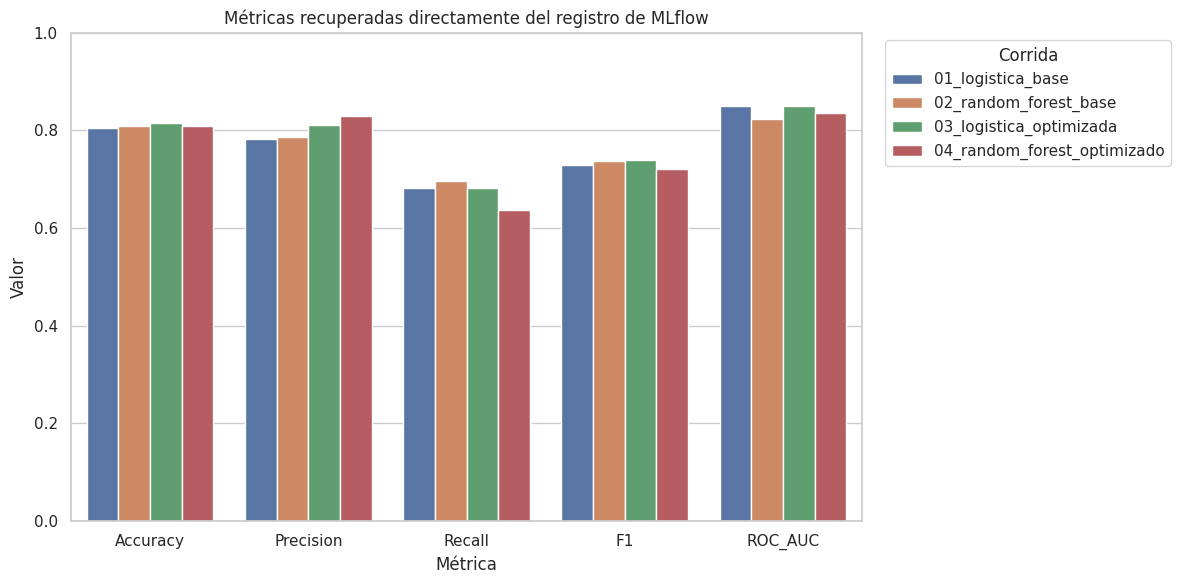

Gráfica guardada en: evidencias/metricas_registradas_mlflow.png


In [36]:
# ============================================================
# 9.5 Evidencia visual de métricas registradas
# ============================================================

metricas_mlflow = tabla_corridas[
    ["Corrida", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
].melt(
    id_vars="Corrida",
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=metricas_mlflow,
    x="Métrica",
    y="Valor",
    hue="Corrida"
)
plt.ylim(0, 1)
plt.title("Métricas recuperadas directamente del registro de MLflow")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.legend(
    title="Corrida",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

RUTA_GRAFICA_MLFLOW = "evidencias/metricas_registradas_mlflow.png"
plt.savefig(RUTA_GRAFICA_MLFLOW, dpi=150, bbox_inches="tight")
plt.show()

print(f"Gráfica guardada en: {RUTA_GRAFICA_MLFLOW}")


### Interpretación de la evidencia

La tabla anterior no se construye a partir de variables temporales del notebook, sino que consulta directamente el almacenamiento de seguimiento de MLflow mediante `mlflow.search_runs()`. Por ello, constituye evidencia de que las métricas y los datos de cada corrida fueron realmente persistidos en el experimento.


# 10. Comparación final de modelos

## ¿Qué se realizará?

Se integrarán las métricas del conjunto de prueba en una tabla y se identificará el modelo con mayor ROC-AUC.

## Resultado esperado

Seleccionar el modelo con mejor equilibrio de desempeño.


In [37]:
# ============================================================
# 10.1 Tabla comparativa
# ============================================================

comparacion = pd.DataFrame([
    {"Modelo": "Regresión Logística", **metricas_logistico},
    {"Modelo": "Random Forest", **metricas_rf},
    {
        "Modelo": "Regresión Logística optimizada",
        **metricas_logistico_optimizado
    },
    {
        "Modelo": "Random Forest optimizado",
        **metricas_rf_optimizado
    }
]).sort_values("roc_auc", ascending=False).reset_index(drop=True)

RUTA_COMPARACION = "resultados/comparacion_modelos.csv"
comparacion.to_csv(RUTA_COMPARACION, index=False)

display(comparacion.style.format({
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc": "{:.4f}"
}))


,Modelo,accuracy,precision,recall,f1,roc_auc
0,Regresión Logística optimizada,0.8156,0.8103,0.6812,0.7402,0.8506
1,Regresión Logística,0.8045,0.7833,0.6812,0.7287,0.8501
2,Random Forest optimizado,0.8101,0.8302,0.6377,0.7213,0.8361
3,Random Forest,0.8101,0.7869,0.6957,0.7385,0.8244


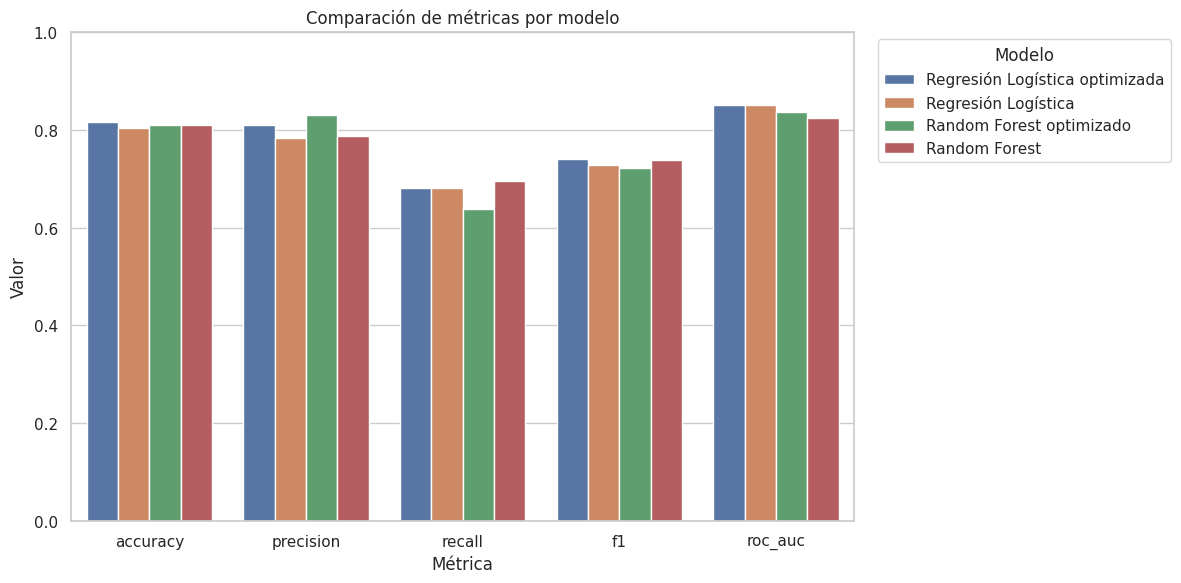

In [38]:
# ============================================================
# 10.2 Visualización comparativa
# ============================================================

comparacion_larga = comparacion.melt(
    id_vars="Modelo",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparacion_larga,
    x="Métrica",
    y="Valor",
    hue="Modelo"
)
plt.ylim(0, 1)
plt.title("Comparación de métricas por modelo")
plt.ylabel("Valor")
plt.xlabel("Métrica")
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [39]:
# ============================================================
# 10.3 Selección automática del mejor modelo
# ============================================================

mejor_fila = comparacion.iloc[0]

print("MEJOR MODELO SEGÚN ROC-AUC")
print("=" * 50)
print("Modelo:", mejor_fila["Modelo"])
print(f"Accuracy: {mejor_fila['accuracy']:.4f}")
print(f"Precision: {mejor_fila['precision']:.4f}")
print(f"Recall: {mejor_fila['recall']:.4f}")
print(f"F1: {mejor_fila['f1']:.4f}")
print(f"ROC-AUC: {mejor_fila['roc_auc']:.4f}")


MEJOR MODELO SEGÚN ROC-AUC
Modelo: Regresión Logística optimizada
Accuracy: 0.8156
Precision: 0.8103
Recall: 0.6812
F1: 0.7402
ROC-AUC: 0.8506


# 11. Conclusiones generales

El proyecto desarrolló un flujo completo de clasificación con el dataset Titanic. Se analizaron los datos, se trataron valores faltantes, se evitaron variables con fuga de información y se generaron versiones identificadas mediante huellas SHA-256.

La Regresión Logística proporcionó una referencia interpretable, mientras que Random Forest permitió representar relaciones no lineales. GridSearchCV y la validación cruzada hicieron posible evaluar configuraciones de manera más sistemática.

MLflow registró correctamente cuatro experimentos: dos modelos base y dos modelos optimizados. Para cada corrida se almacenaron parámetros, métricas, etiquetas, modelos y artefactos. La consulta directa de la base de seguimiento confirmó que las cuatro corridas finalizaron con estado `FINISHED`, por lo que el seguimiento quedó demostrado sin depender de una interfaz web.

La selección final se realiza principalmente con ROC-AUC y se complementa con accuracy, precision, recall, F1 y matrices de confusión. Esto permite elegir un modelo con mejor equilibrio general y no únicamente con el porcentaje de aciertos.


# 12. Limitaciones

- El dataset es relativamente pequeño.
- Algunas variables presentan valores faltantes.
- El problema representa un evento histórico y no una aplicación operativa actual.
- El desempeño depende de la selección de variables y del rango de hiperparámetros evaluado.
- Las métricas de un único conjunto de prueba pueden variar con otra semilla.
- El modelo no debe interpretarse como una explicación causal de la supervivencia.


# 13. Referencias

- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.
- Scikit-learn Developers. *Scikit-learn User Guide*.
- MLflow Project. *MLflow Documentation*.
- Seaborn Developers. *Seaborn Titanic Dataset*.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.


# 14. Uso de herramientas de Inteligencia Artificial

Para realizar esta actividad utilicé ChatGPT como apoyo para organizar el flujo del proyecto, estructurar el notebook y generar un primer borrador del código. Posteriormente revisé la lógica, ejecuté las celdas y analicé los resultados obtenidos. También utilicé Google Colab para ejecutar el proyecto y MLflow para registrar y comparar los experimentos.


# 15. Evidencias para la entrega y GitHub

El notebook genera automáticamente las siguientes evidencias:

- tabla de las cuatro corridas consultadas directamente desde MLflow;
- comprobación automática de que todas terminaron con estado `FINISHED`;
- archivo `evidencias/registro_experimentos_mlflow.csv`;
- gráfica `evidencias/metricas_registradas_mlflow.png`;
- matrices de confusión registradas como artefactos;
- modelos serializados dentro del almacenamiento de MLflow;
- tabla comparativa de los cuatro modelos;
- archivos originales y limpios con sus huellas SHA-256.

## Evidencia

1. La tabla titulada **Evidencia de experimentos registrados en MLflow**.
2. El bloque **COMPROBACIÓN DE MLFLOW** con el resultado correcto.
3. La gráfica de métricas recuperadas desde MLflow.
4. La comparación final de modelos.
5. La matriz de confusión del mejor modelo.



# 16. Ejecución final

Para generar una entrega limpia en Google Colab:

1. Abrir este archivo en Colab.
2. Seleccionar **Entorno de ejecución → Reiniciar sesión**.
3. Seleccionar **Entorno de ejecución → Ejecutar todas**.
4. Esperar a que terminen GridSearchCV y las cuatro corridas de MLflow.
5. Confirmar que aparezca el mensaje:

```text
RESULTADO: REGISTRO DE EXPERIMENTOS COMPLETADO CORRECTAMENTE
```

6. Tomar las capturas recomendadas.
7. Descargar el notebook ejecutado en formato `.ipynb`.
8. Subir el notebook y las evidencias al repositorio de GitHub.

> No es necesario abrir un servidor web de MLflow. La evidencia se obtiene consultando directamente el registro persistente de MLflow y verificando automáticamente sus cuatro corridas.


# 17. Uso ético de la Inteligencia Artificial en esta actividad

Durante el desarrollo de esta actividad se utilizaron herramientas de Inteligencia Artificial, principalmente ChatGPT, como apoyo para estructurar el flujo de trabajo, comprender conceptos relacionados con Machine Learning y MLflow, organizar el código y documentar adecuadamente cada etapa del proceso.

La IA fue empleada como una herramienta de asistencia y no como un sustituto del análisis realizado. Todas las decisiones relacionadas con la preparación de los datos, la selección de modelos, el ajuste de hiperparámetros, la interpretación de resultados y las conclusiones finales fueron revisadas, ejecutadas y validadas por el autor del trabajo.

Asimismo, se verificó el correcto funcionamiento del código mediante su ejecución en Google Colab, realizando las correcciones necesarias cuando surgieron problemas de compatibilidad entre diferentes versiones de las bibliotecas utilizadas. Esto permitió garantizar que los experimentos registrados en MLflow fueran reproducibles y consistentes.

Finalmente, se procuró hacer un uso responsable de la Inteligencia Artificial, empleándola para mejorar la productividad, facilitar el aprendizaje y documentar el proceso de desarrollo, manteniendo siempre el criterio humano en la validación de los resultados obtenidos.

### Principios éticos considerados

- Transparencia en el uso de herramientas de IA durante el desarrollo.
- Validación humana de todos los resultados obtenidos.
- Reproducibilidad de los experimentos mediante MLflow.
- Uso responsable de la IA como herramienta de apoyo y aprendizaje.
- Documentación clara de los procesos y decisiones realizadas.